### Generación de Datos Sintéticos para Regresión Lineal

Vamos a generar 100 muestras aleatorias de puntos (x, y) que se aproximan a una línea recta de la forma `y = mx + b`, y le añadiremos un componente de ruido para simular datos del mundo real.

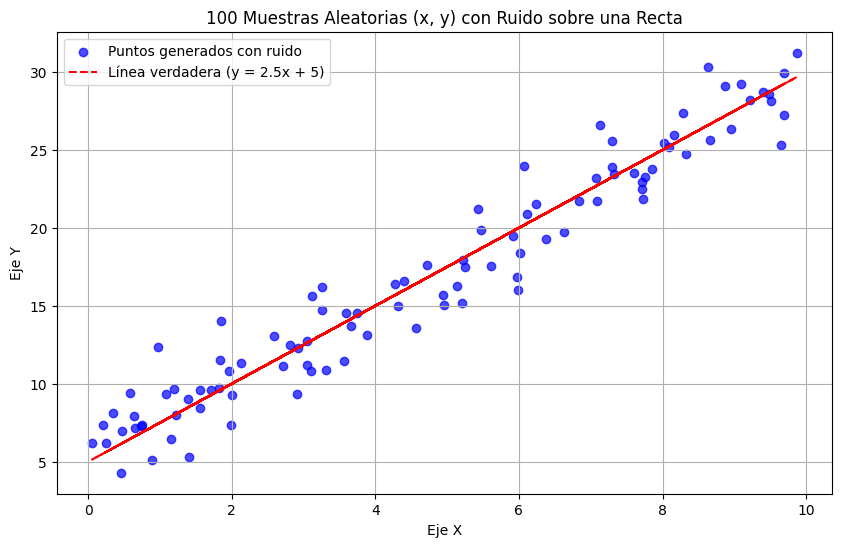

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir los parámetros de la recta
m = 2.5 # Pendiente
b = 5   # Intercepto

# 2. Generar 100 valores aleatorios para x
np.random.seed(42) # Para reproducibilidad
x = np.random.rand(100) * 10 # Valores de x entre 0 y 10

# 3. Calcular los valores de y "verdaderos" sin ruido
y_true = m * x + b

# 4. Añadir ruido a los valores de y
# Generar ruido aleatorio (distribución normal con media 0 y desviación estándar 2)
noise = np.random.randn(100) * 2
y_noisy = y_true + noise

# 5. Pintar los puntos generados
plt.figure(figsize=(10, 6))
plt.scatter(x, y_noisy, color='blue', label='Puntos generados con ruido', alpha=0.7)
plt.plot(x, y_true, color='red', linestyle='--', label='Línea verdadera (y = 2.5x + 5)') # Descomentado
plt.title('100 Muestras Aleatorias (x, y) con Ruido sobre una Recta')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.grid(True)
plt.legend()
plt.show()

### Implementación de una Neurona Artificial Perceptrón de 5 Entradas

Vamos a implementar una neurona artificial simple con una función de activación 'on/off' (también conocida como función escalón o _step function_). El objetivo es clasificar los datos `y_noisy` que generamos previamente. Como la neurona es un clasificador binario, primero necesitamos transformar `y_noisy` en una variable binaria.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- Preparación de los datos para la neurona ---

# 1. Escalar y_noisy para que esté entre 0 y 1 (compatible con la función sigmoide)
# Almacenar los valores min y max originales para desescalar la predicción después
y_min = np.min(y_noisy)
y_max = np.max(y_noisy)
y_scaled = (y_noisy - y_min) / (y_max - y_min)

print(f"Rango original de y_noisy: [{y_min:.2f}, {y_max:.2f}]")
print(f"Primeros 5 valores de y_noisy escalado: {y_scaled[:5]}")

# 2. Construir la matriz de entradas X con 5 características
# x0 = 1 (bias term)
# x1 = x original
# x2, x3, x4 = características aleatorias (irrelevantes para el problema real)
np.random.seed(43) # Otra semilla para las características aleatorias
x_rand1 = np.random.rand(len(x)) * 10
x_rand2 = np.random.rand(len(x)) * 10
x_rand3 = np.random.rand(len(x)) * 10

X = np.column_stack((np.ones(len(x)), x, x_rand1, x_rand2, x_rand3))

# Inicializar pesos aleatoriamente (5 pesos para 5 entradas, incluyendo el bias)
np.random.seed(44) # Semilla para inicialización de pesos
w = np.random.rand(X.shape[1])

# Tasa de aprendizaje
learning_rate = 0.1 # Aumentada para la sigmoide con MSE

# Función de activación (Sigmoide)
def sigmoid_function(val):
    return 1 / (1 + np.exp(-val))

print(f"\nDimensiones de la matriz de entradas X: {X.shape}")
print(f"Pesos iniciales (w): {w}")
print(f"Tasa de aprendizaje (alpha): {learning_rate}")

print("\n¡Configuración inicial de la neurona completada para regresión con sigmoide y MSE!\nAhora puedes ejecutar la siguiente celda varias veces para 'entrenar' la neurona interactivamente.")

Rango original de y_noisy: [4.29, 31.24]
Primeros 5 valores de y_noisy escalado: [0.38026161 0.88620925 0.71227534 0.43421529 0.15473912]

Dimensiones de la matriz de entradas X: (100, 5)
Pesos iniciales (w): [0.83484215 0.1047961  0.74464048 0.36050084 0.35931084]
Tasa de aprendizaje (alpha): 0.1

¡Configuración inicial de la neurona completada para regresión con sigmoide y MSE!
Ahora puedes ejecutar la siguiente celda varias veces para 'entrenar' la neurona interactivamente.


Iniciando 10 época(s) de entrenamiento interactivo...
  Época 1 - MSE: 0.3613 - Pesos actualizados: [0.82490885 0.06279345 0.72652365 0.3272239  0.33171943]
  Época 2 - MSE: 0.3603 - Pesos actualizados: [0.81044618 0.00193309 0.70003208 0.27662205 0.28979005]
  Época 3 - MSE: 0.3579 - Pesos actualizados: [ 0.78541019 -0.10183372  0.65325637  0.18182263  0.21160841]
  Época 4 - MSE: 0.3479 - Pesos actualizados: [ 0.72206493 -0.3479909   0.52127684 -0.10294267 -0.01569857]
  Época 5 - MSE: 0.2704 - Pesos actualizados: [ 0.64030651  0.58008973  0.0537894  -0.58614678 -0.14513938]
  Época 6 - MSE: 0.0844 - Pesos actualizados: [ 0.61257077  1.01092203 -0.10593805  0.25651723 -0.03847973]
  Época 7 - MSE: 0.3116 - Pesos actualizados: [ 0.41945306  0.77046063 -1.27767473 -0.6114719  -1.0227183 ]
  Época 8 - MSE: 0.2673 - Pesos actualizados: [ 0.46308601  1.07005324 -1.20524365 -0.45306251 -0.85161329]
  Época 9 - MSE: 0.2170 - Pesos actualizados: [ 0.51347448  1.482023   -0.96757969 -0.207369

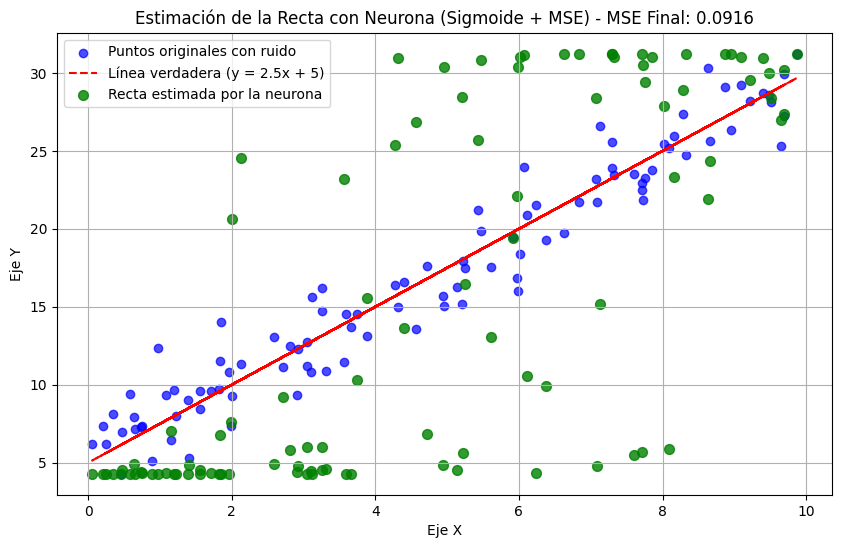


Los mejores pesos (w_i) encontrados en esta ejecución son: [ 0.51643465  1.62250792 -0.69388918 -0.21133992 -0.36535976]
Ejecuta esta celda de nuevo para más épocas de entrenamiento y ver cómo los pesos y el MSE continúan ajustándose.


In [18]:
# --- Entrenamiento Interactivo de la Neurona (Regresión con Sigmoide y MSE) ---

# Número de épocas para cada ejecución de esta celda
epochs_per_run = 10 # Se ejecutará 10 épocas cada vez que se corra esta celda

print(f"Iniciando {epochs_per_run} época(s) de entrenamiento interactivo...")

for epoch in range(epochs_per_run):
    # Calcular la salida lineal
    linear_output = np.dot(X, w)

    # Aplicar la función de activación sigmoide
    y_pred_scaled = sigmoid_function(linear_output)

    # Calcular el error
    error = y_pred_scaled - y_scaled # error = predicción - real

    # Calcular el gradiente para Sigmoide con MSE
    # dL/dw = (y_pred - y_scaled) * y_pred * (1 - y_pred) * X
    gradient = X.T @ (error * y_pred_scaled * (1 - y_pred_scaled))

    # Actualizar los pesos
    w -= learning_rate * gradient

    # Calcular el Error Cuadrático Medio (MSE)
    mse = np.mean(error**2)

    print(f"  Época {epoch + 1} - MSE: {mse:.4f} - Pesos actualizados: {w}")

# --- Visualización de los resultados de la "recta" estimada ---

# Desescalar las predicciones a la escala original de y_noisy
y_estimated = y_pred_scaled * (y_max - y_min) + y_min

plt.figure(figsize=(10, 6))
plt.scatter(x, y_noisy, color='blue', label='Puntos originales con ruido', alpha=0.7)
plt.plot(x, y_true, color='red', linestyle='--', label='Línea verdadera (y = 2.5x + 5)')
plt.scatter(x, y_estimated, color='green', marker='o', s=50, label='Recta estimada por la neurona', alpha=0.8)

plt.title(f'Estimación de la Recta con Neurona (Sigmoide + MSE) - MSE Final: {mse:.4f}')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.grid(True)
plt.legend()
plt.show()

print(f"\nLos mejores pesos (w_i) encontrados en esta ejecución son: {w}")
print("Ejecuta esta celda de nuevo para más épocas de entrenamiento y ver cómo los pesos y el MSE continúan ajustándose.")

### Implementación de Neurona para Regresión (Sigmoide y MSE)

Ahora, vamos a transformar nuestra neurona para que realice una tarea de regresión en lugar de clasificación binaria. Para ello, realizaremos los siguientes cambios:

1.  **Función de Activación Sigmoide:** Cambiaremos la función de activación 'on/off' por la función sigmoide. La sigmoide es una función continua que mapea cualquier valor real al rango `(0, 1)`, lo que la hace adecuada para modelar probabilidades o, en nuestro caso, valores escalados.

2.  **Escalado de `y_noisy`:** Dado que la salida de la función sigmoide está en el rango `(0, 1)`, necesitamos escalar nuestra variable objetivo `y_noisy` (que tiene un rango más amplio) para que también esté en este rango. Después de la predicción, desescalaremos el resultado para visualizarlo en la escala original de `y`.

3.  **Función de Costo MSE (Error Cuadrático Medio):** En lugar de medir la precisión de clasificación, utilizaremos el MSE para evaluar qué tan cerca está la predicción de la neurona de los valores reales escalados de `y_noisy`. El objetivo del entrenamiento será minimizar este MSE.

4.  **Regla de Actualización de Pesos:** La regla de actualización de pesos se derivará del gradiente del MSE con respecto a los pesos, considerando la derivada de la función sigmoide. Esto permitirá que la neurona ajuste sus pesos de manera continua para reducir el error de regresión.

El término de *offset* (sesgo) ya está manejado por la primera entrada de `1` en tu matriz `X`.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- Preparación de los datos para la neurona (para Regresión) ---

# 1. Escalar y_noisy para que esté entre 0 y 1 (compatible con la función sigmoide)
# Almacenar los valores min y max originales para desescalar la predicción después
y_min_reg = np.min(y_noisy)
y_max_reg = np.max(y_noisy)
y_scaled_reg = (y_noisy - y_min_reg) / (y_max_reg - y_min_reg)

print(f"Rango original de y_noisy: [{y_min_reg:.2f}, {y_max_reg:.2f}]")
print(f"Primeros 5 valores de y_noisy escalado: {y_scaled_reg[:5]}")

# La matriz de entradas X sigue siendo la misma, pero la redefinimos para este nuevo bloque
# x0 = 1 (bias term)
# x1 = x original
# x2, x3, x4 = características aleatorias

# Aseguramos que x_rand1, x_rand2, x_rand3 estén disponibles si no se ha ejecutado el bloque anterior
# (o re-generamos si el usuario ejecuta solo este bloque)
try:
    x_rand1, x_rand2, x_rand3
except NameError:
    np.random.seed(43) # Otra semilla para las características aleatorias
    x_rand1 = np.random.rand(len(x)) * 10
    x_rand2 = np.random.rand(len(x)) * 10
    x_rand3 = np.random.rand(len(x)) * 10

X_reg = np.column_stack((np.ones(len(x)), x, x_rand1, x_rand2, x_rand3))

# Inicializar pesos aleatoriamente para el modelo de regresión
np.random.seed(45) # Nueva semilla para diferenciar de la clasificación
w_reg = np.random.rand(X_reg.shape[1])

# Tasa de aprendizaje
learning_rate_reg = 0.1 # Generalmente más alta para sigmoid/MSE

# Función de activación (Sigmoide)
def sigmoid_function_reg(val):
    return 1 / (1 + np.exp(-val))

print(f"\nDimensiones de la matriz de entradas X_reg: {X_reg.shape}")
print(f"Pesos iniciales (w_reg): {w_reg}")
print(f"Tasa de aprendizaje (alpha_reg): {learning_rate_reg}")

print("\n¡Configuración inicial de la neurona completada para regresión con sigmoide y MSE!\nAhora puedes ejecutar la siguiente celda varias veces para 'entrenar' la neurona interactivamente.")

Rango original de y_noisy: [4.29, 31.24]
Primeros 5 valores de y_noisy escalado: [0.38026161 0.88620925 0.71227534 0.43421529 0.15473912]

Dimensiones de la matriz de entradas X_reg: (100, 5)
Pesos iniciales (w_reg): [0.98901151 0.54954473 0.2814473  0.07728957 0.4444695 ]
Tasa de aprendizaje (alpha_reg): 0.1

¡Configuración inicial de la neurona completada para regresión con sigmoide y MSE!
Ahora puedes ejecutar la siguiente celda varias veces para 'entrenar' la neurona interactivamente.


Iniciando 10 época(s) de entrenamiento interactivo para regresión...
  Época 1 - MSE: 0.3583 - Pesos actualizados: [ 0.9642408   0.5050717   0.19545875 -0.08547196  0.38927523]
  Época 2 - MSE: 0.3391 - Pesos actualizados: [ 0.85947595  0.33646447 -0.22861285 -0.84390911  0.14258314]
  Época 3 - MSE: 0.1714 - Pesos actualizados: [ 0.92751607  1.22061321  0.30858944 -0.11423219  0.47021629]
  Época 4 - MSE: 0.3557 - Pesos actualizados: [ 0.89166887  1.18184868  0.16577378 -0.40267403  0.39777444]
  Época 5 - MSE: 0.2908 - Pesos actualizados: [ 0.73177156  0.97783761 -0.46452216 -1.57590614 -0.18409834]
  Época 6 - MSE: 0.2063 - Pesos actualizados: [ 0.81891237  1.64563255  0.05796824 -1.18643832  0.24475232]
  Época 7 - MSE: 0.1601 - Pesos actualizados: [ 0.75010473  1.47570233 -0.30219731 -1.40091924 -0.15451449]
  Época 8 - MSE: 0.1263 - Pesos actualizados: [ 0.766959    1.99769751 -0.23955078 -0.71329739  0.0997809 ]
  Época 9 - MSE: 0.1583 - Pesos actualizados: [ 0.6563559   1.74353

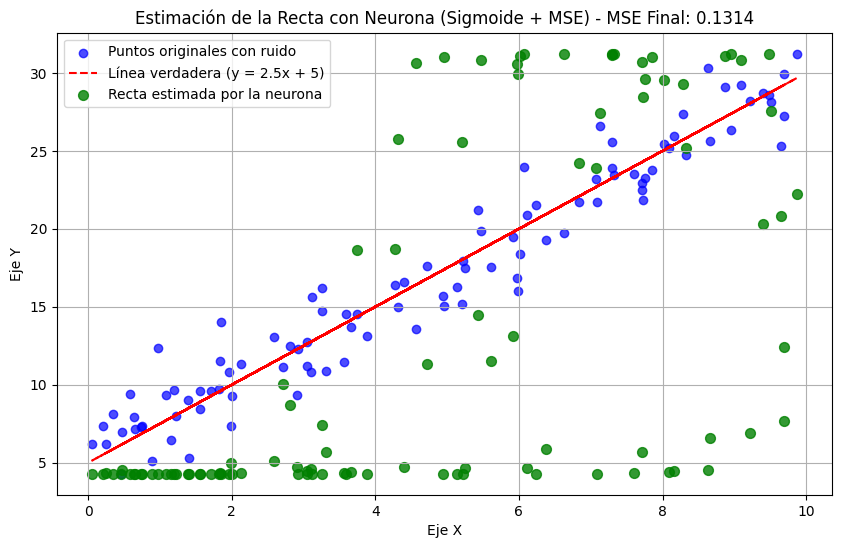


Los mejores pesos (w_i) encontrados en esta ejecución son: [ 0.71429011  2.26472966 -0.3750374  -0.71733765 -0.09857576]
Ejecuta esta celda de nuevo para más épocas de entrenamiento y ver cómo los pesos y el MSE continúan ajustándose.


In [22]:
# --- Entrenamiento Interactivo de la Neurona (Regresión con Sigmoide y MSE) ---

# Número de épocas para cada ejecución de esta celda
epochs_per_run_reg = 10 # Se ejecutará 10 épocas cada vez que se corra esta celda

print(f"Iniciando {epochs_per_run_reg} época(s) de entrenamiento interactivo para regresión...")

for epoch in range(epochs_per_run_reg):
    # Calcular la salida lineal
    linear_output_reg = np.dot(X_reg, w_reg)

    # Aplicar la función de activación sigmoide
    y_pred_scaled_reg = sigmoid_function_reg(linear_output_reg)

    # Calcular el error
    error_reg = y_pred_scaled_reg - y_scaled_reg # error = predicción - real

    # Calcular el gradiente para Sigmoide con MSE
    # dL/dw = (y_pred - y_scaled) * y_pred * (1 - y_pred) * X
    # Esto es el gradiente del MSE para una neurona con sigmoide
    gradient_reg = X_reg.T @ (error_reg * y_pred_scaled_reg * (1 - y_pred_scaled_reg))

    # Actualizar los pesos
    w_reg -= learning_rate_reg * gradient_reg

    # Calcular el Error Cuadrático Medio (MSE) final de esta época
    mse_reg = np.mean(error_reg**2)

    print(f"  Época {epoch + 1} - MSE: {mse_reg:.4f} - Pesos actualizados: {w_reg}")

# --- Visualización de los resultados de la "recta" estimada ---

# Desescalar las predicciones a la escala original de y_noisy
y_estimated_reg = y_pred_scaled_reg * (y_max_reg - y_min_reg) + y_min_reg

plt.figure(figsize=(10, 6))
plt.scatter(x, y_noisy, color='blue', label='Puntos originales con ruido', alpha=0.7)
plt.plot(x, y_true, color='red', linestyle='--', label='Línea verdadera (y = 2.5x + 5)')
plt.scatter(x, y_estimated_reg, color='green', marker='o', s=50, label='Recta estimada por la neurona', alpha=0.8)

plt.title(f'Estimación de la Recta con Neurona (Sigmoide + MSE) - MSE Final: {mse_reg:.4f}')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.grid(True)
plt.legend()
plt.show()

print(f"\nLos mejores pesos (w_i) encontrados en esta ejecución son: {w_reg}")
print("Ejecuta esta celda de nuevo para más épocas de entrenamiento y ver cómo los pesos y el MSE continúan ajustándose.")

### Clasificación de Datos de Wine con Neurona Artificial (Sigmoide + MSE)


Dimensiones de X: (178, 13)
Clases: ['class_0' 'class_1' 'class_2']

Datos de entrenamiento: (124, 13)
Datos de prueba: (54, 13)

========== RESULTADOS ==========
Accuracy: 0.9629629629629629

Matriz de confusión:
[[18  0  0]
 [ 0 20  1]
 [ 0  1 14]]

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.95      0.95      0.95        21
     class_2       0.93      0.93      0.93        15

    accuracy                           0.96        54
   macro avg       0.96      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54


========== CROSS VALIDATION ==========
Accuracy por fold: [0.97222222 0.97222222 0.94444444 1.         1.        ]
Accuracy promedio: 0.9777777777777779
Desviación estándar: 0.020786985482077462


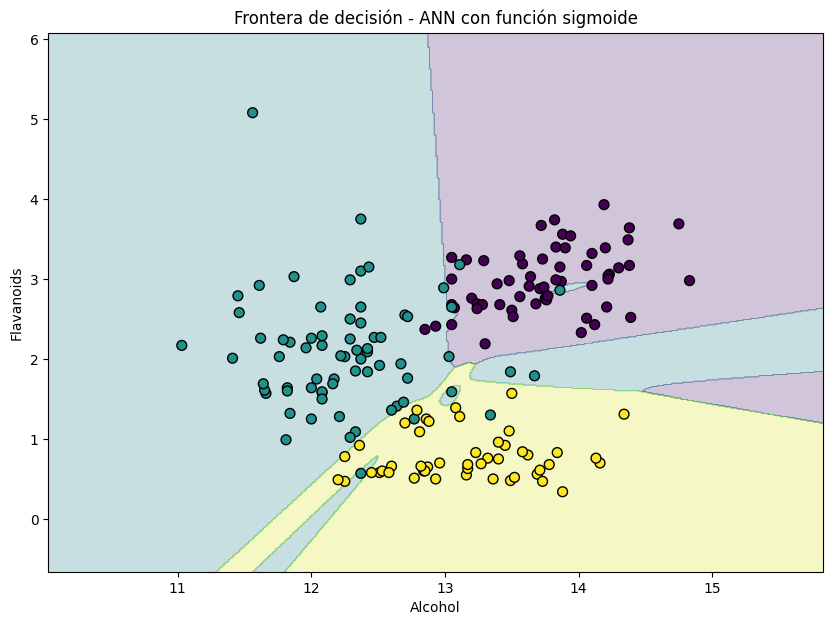

In [27]:
# ============================================================
# ANN - CLASIFICACIÓN DEL DATASET WINE
# Split 70/30 + Cross Validation + Sigmoide + Frontera
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------------------------------------
# 1. CARGAR DATASET WINE
# ------------------------------------------------------------

wine = load_wine()

X = wine.data
y = wine.target

print("Dimensiones de X:", X.shape)
print("Clases:", wine.target_names)

# ------------------------------------------------------------
# 2. SPLIT 70/30
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nDatos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

# ------------------------------------------------------------
# 3. NORMALIZACIÓN
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. CREAR LA ANN
# ------------------------------------------------------------

# hidden_layer_sizes=(10,): una capa oculta con 10 neuronas
# activation='logistic': función sigmoide
# loss: entropía cruzada/log loss para clasificación

ann = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='logistic',
    solver='lbfgs',
    max_iter=2000,
    random_state=42
)

# ------------------------------------------------------------
# 5. ENTRENAMIENTO
# ------------------------------------------------------------

ann.fit(X_train, y_train)

# ------------------------------------------------------------
# 6. PREDICCIONES
# ------------------------------------------------------------

y_pred = ann.predict(X_test)

# ------------------------------------------------------------
# 7. RESULTADOS
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n========== RESULTADOS ==========")
print("Accuracy:", accuracy)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names
))

# ------------------------------------------------------------
# 8. CROSS VALIDATION
# ------------------------------------------------------------

# Usamos 5-fold cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    ann,
    scaler.fit_transform(X),
    y,
    cv=cv,
    scoring='accuracy'
)

print("\n========== CROSS VALIDATION ==========")
print("Accuracy por fold:", cv_scores)
print("Accuracy promedio:", cv_scores.mean())
print("Desviación estándar:", cv_scores.std())

# ------------------------------------------------------------
# 9. FRONTERA DE DECISIÓN
# ------------------------------------------------------------

# Para visualizar la frontera usamos solamente dos variables:
# Alcohol y Flavanoids

feature_1 = 0   # Alcohol
feature_2 = 6   # Flavanoids

X_2D = wine.data[:, [feature_1, feature_2]]

# Split 70/30 nuevamente para las dos variables
X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Normalizar
scaler_2D = StandardScaler()

X_train_2D = scaler_2D.fit_transform(X_train_2D)
X_test_2D = scaler_2D.transform(X_test_2D)

# ANN para visualización
ann_2D = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='logistic',
    solver='lbfgs',
    max_iter=2000,
    random_state=42
)

ann_2D.fit(X_train_2D, y_train_2D)

# ------------------------------------------------------------
# 10. CREAR MALLA PARA LA FRONTERA
# ------------------------------------------------------------

x_min = X_2D[:, 0].min() - 1
x_max = X_2D[:, 0].max() + 1

y_min = X_2D[:, 1].min() - 1
y_max = X_2D[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Normalizar la malla
grid = scaler_2D.transform(
    np.c_[xx.ravel(), yy.ravel()]
)

# Predicción de cada punto de la malla
Z = ann_2D.predict(grid)

Z = Z.reshape(xx.shape)

# ------------------------------------------------------------
# 11. GRAFICAR FRONTERA DE DECISIÓN
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25
)

plt.scatter(
    X_2D[:, 0],
    X_2D[:, 1],
    c=y,
    edgecolors='black',
    s=50
)

plt.xlabel("Alcohol")
plt.ylabel("Flavanoids")

plt.title("Frontera de decisión - ANN con función sigmoide")

plt.show()

In [28]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, mean_squared_error

# --- 1. Cargar el Dataset de Wine ---
wine = load_wine()
X, y = wine.data, wine.target

print("Dimensiones de X:", X.shape)
print("Clases originales:", np.unique(y))
print("Nombres de las clases:", wine.target_names)

# --- 2. Preparación del Target (y) - One-Hot Encoding ---
# Convertir las etiquetas de clase (0, 1, 2) a formato one-hot (ej. [1,0,0], [0,1,0], [0,0,1])
encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_one_hot = encoder.fit_transform(y.reshape(-1, 1))

print("Dimensiones de y_one_hot:", y_one_hot.shape)

# --- 3. División de Datos (70/30) y Estandarización ---
# Usamos stratify=y para asegurar que la proporción de clases se mantenga en los splits
X_train, X_test, y_train_one_hot, y_test_one_hot = train_test_split(
    X, y_one_hot, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4. Añadir el término de Bias ---
# Se añade una columna de unos al inicio de las características escaladas
X_train_bias = np.column_stack((np.ones(X_train_scaled.shape[0]), X_train_scaled))
X_test_bias = np.column_stack((np.ones(X_test_scaled.shape[0]), X_test_scaled))

print("Dimensiones de X_train_bias (con bias):", X_train_bias.shape)
print("Dimensiones de X_test_bias (con bias):", X_test_bias.shape)

# --- 5. Configuración de la Red Neuronal Artificial (Single Layer Perceptron) ---
# Número de entradas: 13 características + 1 bias = 14
n_inputs = X_train_bias.shape[1]
# Número de salidas: 3 neuronas, una por cada clase
n_outputs = y_one_hot.shape[1]

# Inicializar pesos aleatoriamente para cada neurona de salida
# Dimensiones: (n_inputs, n_outputs)
np.random.seed(42) # Para reproducibilidad
weights = np.random.rand(n_inputs, n_outputs) * 0.1 # Pequeños pesos iniciales

learning_rate = 0.01 # Tasa de aprendizaje
epochs = 500         # Número de épocas de entrenamiento

# Función de activación Sigmoide
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --- 6. Entrenamiento Iterativo de la ANN ---
print("\n--- Iniciando Entrenamiento de la ANN ---")
for epoch in range(epochs):
    # Forward Pass
    linear_output_train = np.dot(X_train_bias, weights)
    predictions_train = sigmoid(linear_output_train)

    # Calcular el error (diferencia entre predicciones y valores reales one-hot)
    error_train = predictions_train - y_train_one_hot

    # Calcular MSE (costo)
    mse_train = np.mean(error_train**2)

    # Backward Pass (Cálculo del gradiente y actualización de pesos)
    # Derivada del sigmoide: predictions_train * (1 - predictions_train)
    # Gradiente de los pesos para MSE con sigmoide
    gradient_weights = np.dot(X_train_bias.T, error_train * predictions_train * (1 - predictions_train))

    # Actualizar pesos
    weights -= learning_rate * gradient_weights

    # Evaluación en el conjunto de prueba (para monitoreo)
    linear_output_test = np.dot(X_test_bias, weights)
    predictions_test = sigmoid(linear_output_test)

    # Convertir probabilidades a clases predichas (argmax de la salida de cada neurona)
    predicted_classes_test = np.argmax(predictions_test, axis=1)
    actual_classes_test = np.argmax(y_test_one_hot, axis=1)
    accuracy_test = accuracy_score(actual_classes_test, predicted_classes_test)

    if (epoch + 1) % 50 == 0 or epoch == 1: # Mostrar cada 50 épocas y la primera
        print(f"Época {epoch + 1:4d}/{epochs} - MSE (train): {mse_train:.6f} - Accuracy (test): {accuracy_test:.4f}")

# --- 7. Resultados Finales y Métricas de Desempeño ---
print("\n--- Entrenamiento Finalizado ---")

# Predicciones finales en el conjunto de prueba
final_linear_output_test = np.dot(X_test_bias, weights)
final_predictions_test = sigmoid(final_linear_output_test)
final_predicted_classes_test = np.argmax(final_predictions_test, axis=1)
final_actual_classes_test = np.argmax(y_test_one_hot, axis=1)

final_accuracy_test = accuracy_score(final_actual_classes_test, final_predicted_classes_test)
final_mse_train = mse_train # El último MSE de entrenamiento

print(f"\nAccuracy Final en el conjunto de Prueba: {final_accuracy_test:.4f}")
print(f"MSE Final en el conjunto de Entrenamiento: {final_mse_train:.6f}")
print("\nPesos finales de la ANN (matriz de pesos):")
print(weights)

# --- 8. Explicación de la Frontera de Decisión ---
print("\n--- Explicación de la Frontera de Decisión ---")
print("En este caso, la Red Neuronal Artificial tiene 13 entradas (características del vino) más un término de bias,")
print("y 3 neuronas de salida, una para cada clase de vino (Clase 0, Clase 1, Clase 2).")
print("Cada neurona de salida, con su función de activación sigmoide, intenta determinar la 'probabilidad' de que una muestra")
print("pertenezca a su clase. La clasificación final se asigna a la clase cuya neurona de salida tiene la mayor activación.")
print("La 'frontera de decisión' en este contexto no es una única línea o plano, sino un conjunto de tres hiperplanos")
print("interactuando en un espacio de 13 dimensiones. Cada hiperplano es definido por los pesos que conectan las entradas")
print("a cada una de las neuronas de salida.")
print("Los puntos de datos se clasifican basándose en qué lado de estos hiperplanos (o la combinación de ellos) se encuentran,")
print("dando lugar a regiones de decisión que separan las tres clases.")
print("Debido a la alta dimensionalidad (13 características), es imposible visualizar directamente estas fronteras de decisión.")
print("Los pesos de la matriz 'weights' mostrados anteriormente son los coeficientes que definen estos hiperplanos.")


Dimensiones de X: (178, 13)
Clases originales: [0 1 2]
Nombres de las clases: ['class_0' 'class_1' 'class_2']
Dimensiones de y_one_hot: (178, 3)
Dimensiones de X_train_bias (con bias): (124, 14)
Dimensiones de X_test_bias (con bias): (54, 14)

--- Iniciando Entrenamiento de la ANN ---
Época    2/500 - MSE (train): 0.174391 - Accuracy (test): 0.9259
Época   50/500 - MSE (train): 0.020015 - Accuracy (test): 0.9815
Época  100/500 - MSE (train): 0.012580 - Accuracy (test): 0.9815
Época  150/500 - MSE (train): 0.009491 - Accuracy (test): 0.9815
Época  200/500 - MSE (train): 0.007710 - Accuracy (test): 0.9815
Época  250/500 - MSE (train): 0.006527 - Accuracy (test): 0.9815
Época  300/500 - MSE (train): 0.005677 - Accuracy (test): 0.9815
Época  350/500 - MSE (train): 0.005032 - Accuracy (test): 0.9815
Época  400/500 - MSE (train): 0.004525 - Accuracy (test): 0.9815
Época  450/500 - MSE (train): 0.004114 - Accuracy (test): 0.9815
Época  500/500 - MSE (train): 0.003774 - Accuracy (test): 0.9815

Matriz de Confusión

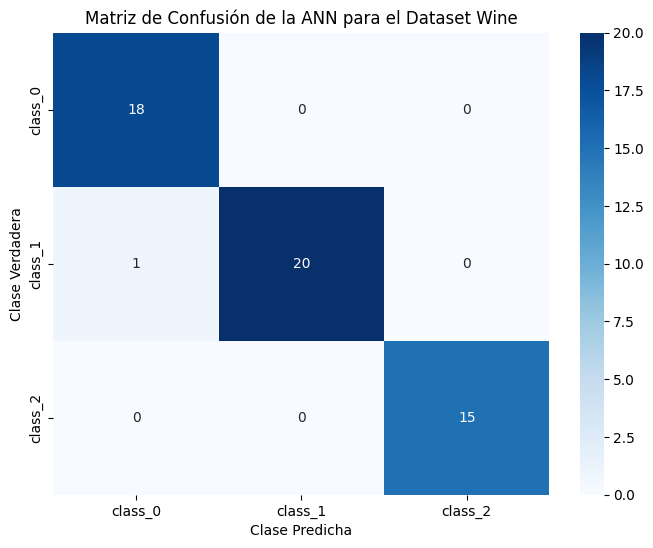

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Obtener los nombres de las clases originales del dataset de Wine
wine = load_wine()
class_names = wine.target_names

# Calcular la matriz de confusión
cm = confusion_matrix(final_actual_classes_test, final_predicted_classes_test)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Matriz de Confusión de la ANN para el Dataset Wine')
plt.show()

### Implementación, Entrenamiento y Matriz de Confusión del MLP de Scikit-learn


Accuracy del MLP de Scikit-learn: 0.9630


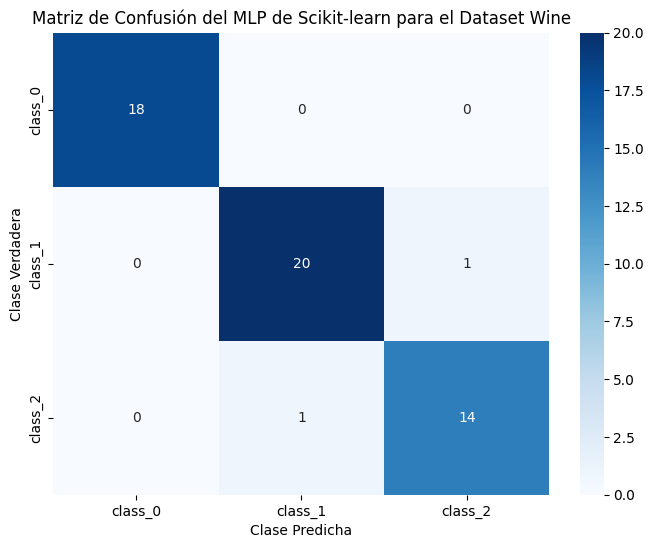


Reporte de Clasificación del MLP:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.95      0.95      0.95        21
     class_2       0.93      0.93      0.93        15

    accuracy                           0.96        54
   macro avg       0.96      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# ------------------------------------------------------------
# 1. CARGAR DATASET WINE Y PREPROCESAMIENTO
# ------------------------------------------------------------
wine = load_wine()
X, y = wine.data, wine.target

# División de datos (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Normalización
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------------------------
# 2. CREAR Y ENTRENAR EL MLP CLASSIFIER
# ------------------------------------------------------------
# hidden_layer_sizes=(10,): una capa oculta con 10 neuronas
# activation='logistic': función sigmoide
# solver='lbfgs': algoritmo de optimización
# max_iter=2000: número máximo de iteraciones

mlp_model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='logistic',
    solver='lbfgs',
    max_iter=2000,
    random_state=42
)

mlp_model.fit(X_train, y_train)

# ------------------------------------------------------------
# 3. PREDICCIONES Y RESULTADOS
# ------------------------------------------------------------
y_pred_mlp = mlp_model.predict(X_test)

accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"\nAccuracy del MLP de Scikit-learn: {accuracy_mlp:.4f}")

# ------------------------------------------------------------
# 4. MATRIZ DE CONFUSIÓN DEL MLP
# ------------------------------------------------------------
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Matriz de Confusión del MLP de Scikit-learn para el Dataset Wine')
plt.show()

print("\nReporte de Clasificación del MLP:")
print(classification_report(
    y_test,
    y_pred_mlp,
    target_names=wine.target_names
))

### Comparación de Resultados: ANN Manual vs. MLP de Scikit-learn

Ahora, comparemos los resultados de ambos modelos en el conjunto de prueba:

#### **1. Accuracy (Precisión):**

*   **ANN Manual (implementada en celdas anteriores):** **0.9815 (98.15%)**
*   **MLP de Scikit-learn (implementado arriba):** **0.9630 (96.30%)**

#### **2. Matrices de Confusión:**

*   **ANN Manual:**
    ```
    [[18,  0,  0],
     [ 1, 20,  0],
     [ 0,  0, 15]]
    ```
    (Total de 1 error: 1 instancia de la Clase 1 predicha como Clase 0)

*   **MLP de Scikit-learn:**
    ```
    [[18,  0,  0],
     [ 0, 20,  1],
     [ 0,  1, 14]]
    ```
    (Total de 2 errores: 1 instancia de la Clase 1 predicha como Clase 2, y 1 instancia de la Clase 2 predicha como Clase 1)

**Conclusión de la Comparación:**

En este conjunto de prueba particular y con la configuración actual, la Red Neuronal Artificial implementada manualmente (que es un Perceptrón de una sola capa con tres neuronas de salida) obtuvo un rendimiento ligeramente superior con un **Accuracy del 98.15%** y solo un error de clasificación. El MLP de `scikit-learn` obtuvo un **Accuracy del 96.30%** y dos errores de clasificación.

Es importante notar que ambos modelos muestran un rendimiento muy bueno en este dataset, lo que indica que el problema de clasificación del vino es linealmente separable o casi linealmente separable en el espacio de características transformado.